In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Convert to DataFrame
df = housing.frame

# Display first 5 rows
print(df.head())

# Display dataset shape
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [3]:
# Select input features
X = df[['MedInc', 'HouseAge']].values

# Select target
y = df['MedHouseVal'].values.reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 2)
y shape: (20640, 1)


In [4]:
print("Missing values in X:")
print(np.isnan(X).sum(axis=0))

print("\nMissing values in y:")
print(np.isnan(y).sum())

Missing values in X:
[0 0]

Missing values in y:
0


In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = X.shape[0]

# Shuffle indices
indices = np.random.permutation(n_samples)

# Calculate training size
train_size = int(0.80 * n_samples)

# Training indices
train_indices = indices[:train_size]

# Testing indices
test_indices = indices[train_size:]

# Create train/test sets
X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [7]:
# Calculate mean and standard deviation using training data only
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Normalize training data
X_train = (X_train - mean) / std

# Normalize test data using training mean/std
X_test = (X_test - mean) / std

print("Training feature means:")
print(np.mean(X_train, axis=0))

print("\nTraining feature standard deviations:")
print(np.std(X_train, axis=0))

Training feature means:
[-9.81836846e-15 -6.79904023e-17]

Training feature standard deviations:
[1. 1.]


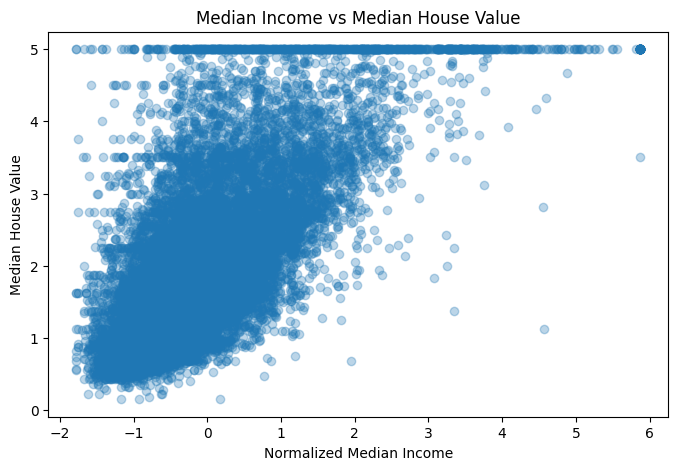

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train[:, 0],
    y_train,
    alpha=0.3
)

plt.xlabel("Normalized Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")

plt.show()

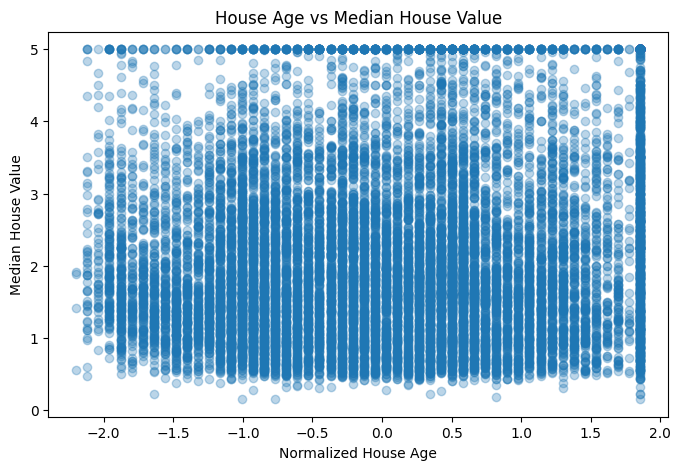

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train[:, 1],
    y_train,
    alpha=0.3
)

plt.xlabel("Normalized House Age")
plt.ylabel("Median House Value")
plt.title("House Age vs Median House Value")

plt.show()

In [10]:
def relu(x):
    return np.maximum(0, x)

In [11]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [12]:
def initialize_parameters(seed=42):

    np.random.seed(seed)

    W1 = np.random.randn(2, 5) * np.sqrt(2 / 2)
    b1 = np.zeros((1, 5))

    W2 = np.random.randn(5, 3) * np.sqrt(2 / 5)
    b2 = np.zeros((1, 3))

    W3 = np.random.randn(3, 1) * np.sqrt(2 / 3)
    b3 = np.zeros((1, 1))

    parameters = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2,
        'W3': W3,
        'b3': b3
    }

    return parameters

In [13]:
def forward_propagation(X, parameters):

    W1 = parameters['W1']
    b1 = parameters['b1']
    W2 = parameters['W2']
    b2 = parameters['b2']
    W3 = parameters['W3']
    b3 = parameters['b3']

    # Layer 1
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = A2 @ W3 + b3
    y_pred = Z3

    cache = {
        'X': X,
        'Z1': Z1,
        'A1': A1,
        'Z2': Z2,
        'A2': A2,
        'Z3': Z3
    }

    return y_pred, cache

In [14]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [15]:
def backward_propagation(y_true, y_pred, parameters, cache, l2_lambda=0.0):

    X = cache['X']
    Z1 = cache['Z1']
    A1 = cache['A1']
    Z2 = cache['Z2']
    A2 = cache['A2']

    W1 = parameters['W1']
    W2 = parameters['W2']
    W3 = parameters['W3']

    m = X.shape[0]

    # Derivative of MSE
    dZ3 = (2 / m) * (y_pred - y_true)

    # Layer 3 gradients
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Backprop through layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Backprop through layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # L2 regularization
    if l2_lambda > 0:
        dW1 += 2 * l2_lambda * W1
        dW2 += 2 * l2_lambda * W2
        dW3 += 2 * l2_lambda * W3

    gradients = {
        'W1': dW1,
        'b1': db1,
        'W2': dW2,
        'b2': db2,
        'W3': dW3,
        'b3': db3
    }

    return gradients

In [16]:
def update_gradient_descent(parameters, gradients, learning_rate):

    for key in parameters:
        parameters[key] -= learning_rate * gradients[key]

    return parameters

In [17]:
def initialize_momentum(parameters):

    velocity = {}

    for key in parameters:
        velocity[key] = np.zeros_like(parameters[key])

    return velocity

In [18]:
def update_momentum(parameters, gradients, velocity, learning_rate, beta=0.9):

    for key in parameters:

        velocity[key] = (
            beta * velocity[key]
            + (1 - beta) * gradients[key]
        )

        parameters[key] -= learning_rate * velocity[key]

    return parameters, velocity

In [19]:
def initialize_adam(parameters):

    m = {}
    v = {}

    for key in parameters:
        m[key] = np.zeros_like(parameters[key])
        v[key] = np.zeros_like(parameters[key])

    return m, v

In [21]:
def update_adam(
    parameters,
    gradients,
    m,
    v,
    learning_rate,
    t,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):

    for key in parameters:

        # First moment
        m[key] = beta1 * m[key] + (1 - beta1) * gradients[key]

        # Second moment
        v[key] = beta2 * v[key] + (1 - beta2) * (gradients[key] ** 2)

        # Bias correction
        m_hat = m[key] / (1 - beta1 ** t)
        v_hat = v[key] / (1 - beta2 ** t)

        # Adam update
        parameters[key] -= (
            learning_rate
            * m_hat
            / (np.sqrt(v_hat) + epsilon)
        )

    return parameters, m, v

In [22]:
def train_model(
    X_train,
    y_train,
    optimizer='gd',
    learning_rate=0.01,
    epochs=1000,
    l2_lambda=0.0,
    print_every=100
):

    parameters = initialize_parameters(seed=42)

    # Initialize optimizer variables
    if optimizer == 'momentum':
        velocity = initialize_momentum(parameters)

    elif optimizer == 'adam':
        m, v = initialize_adam(parameters)

    losses = []

    for epoch in range(1, epochs + 1):

        # Forward propagation
        y_pred, cache = forward_propagation(
            X_train,
            parameters
        )

        # Calculate loss
        loss = mse_loss(y_train, y_pred)

        # Add L2 penalty if required
        if l2_lambda > 0:
            regularization = (
                l2_lambda *
                (
                    np.sum(parameters['W1'] ** 2) +
                    np.sum(parameters['W2'] ** 2) +
                    np.sum(parameters['W3'] ** 2)
                )
            )

            loss += regularization

        losses.append(loss)

        # Backpropagation
        gradients = backward_propagation(
            y_train,
            y_pred,
            parameters,
            cache,
            l2_lambda
        )

        # Update parameters
        if optimizer == 'gd':

            parameters = update_gradient_descent(
                parameters,
                gradients,
                learning_rate
            )

        elif optimizer == 'momentum':

            parameters, velocity = update_momentum(
                parameters,
                gradients,
                velocity,
                learning_rate
            )

        elif optimizer == 'adam':

            parameters, m, v = update_adam(
                parameters,
                gradients,
                m,
                v,
                learning_rate,
                epoch
            )

        # Print progress
        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch}/{epochs}, Loss: {loss:.6f}"
            )

    return parameters, losses

In [23]:
gd_params, gd_losses = train_model(
    X_train,
    y_train,
    optimizer='gd',
    learning_rate=0.01,
    epochs=1000
)

Epoch 1/1000, Loss: 9.531136
Epoch 100/1000, Loss: 1.395361
Epoch 200/1000, Loss: 1.218699
Epoch 300/1000, Loss: 0.989162
Epoch 400/1000, Loss: 0.899199
Epoch 500/1000, Loss: 0.834348
Epoch 600/1000, Loss: 0.752851
Epoch 700/1000, Loss: 0.714711
Epoch 800/1000, Loss: 0.695933
Epoch 900/1000, Loss: 0.683747
Epoch 1000/1000, Loss: 0.674503


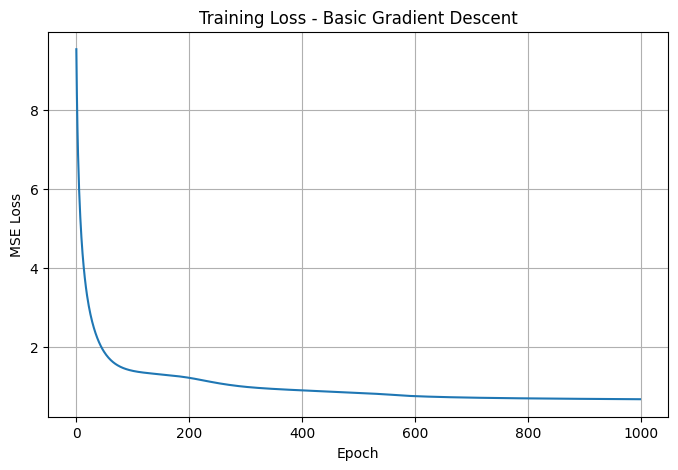

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(gd_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss - Basic Gradient Descent")

plt.grid(True)
plt.show()

In [25]:
# Predictions
gd_predictions, _ = forward_propagation(
    X_test,
    gd_params
)

# Test MSE
gd_mse = mse_loss(
    y_test,
    gd_predictions
)

# RMSE
gd_rmse = np.sqrt(gd_mse)

print("Basic Gradient Descent")
print("----------------------")
print("Test MSE :", gd_mse)
print("Test RMSE:", gd_rmse)

Basic Gradient Descent
----------------------
Test MSE : 0.6983792744956822
Test RMSE: 0.8356908965016204


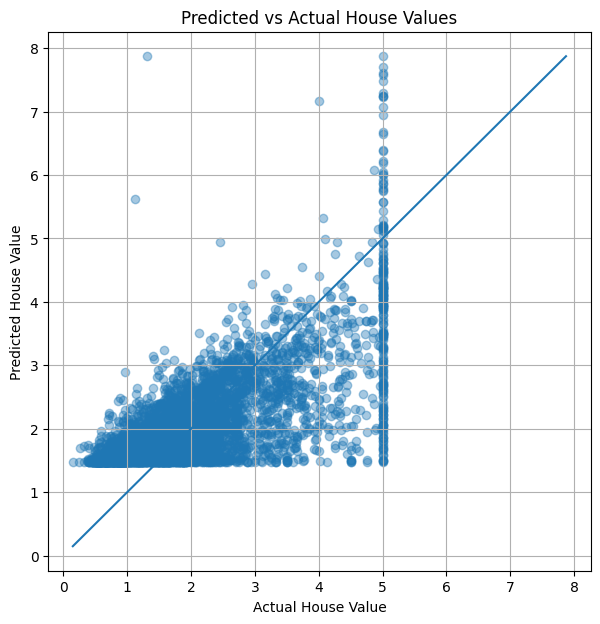

In [26]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    gd_predictions,
    alpha=0.4
)

# Perfect prediction line
minimum = min(y_test.min(), gd_predictions.min())
maximum = max(y_test.max(), gd_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual House Values")

plt.grid(True)
plt.show()

In [27]:
gd_params_001, gd_losses_001 = train_model(
    X_train,
    y_train,
    optimizer='gd',
    learning_rate=0.001,
    epochs=1000
)

Epoch 1/1000, Loss: 9.531136
Epoch 100/1000, Loss: 4.639323
Epoch 200/1000, Loss: 3.242941
Epoch 300/1000, Loss: 2.556040
Epoch 400/1000, Loss: 2.140140
Epoch 500/1000, Loss: 1.869019
Epoch 600/1000, Loss: 1.688598
Epoch 700/1000, Loss: 1.567989
Epoch 800/1000, Loss: 1.486927
Epoch 900/1000, Loss: 1.431879
Epoch 1000/1000, Loss: 1.393822


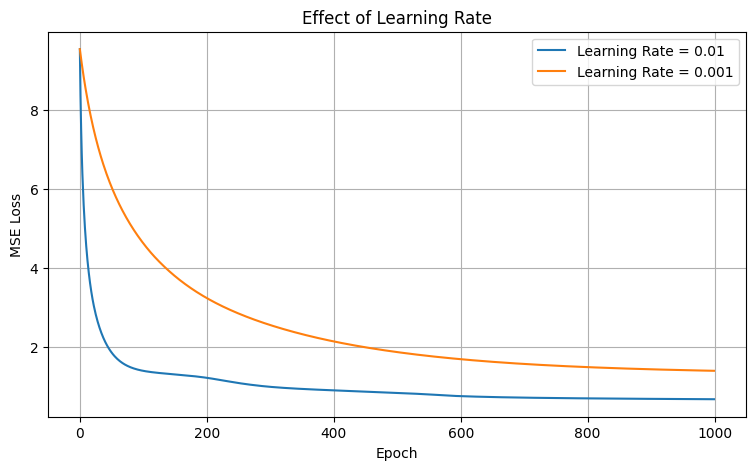

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    gd_losses,
    label="Learning Rate = 0.01"
)

plt.plot(
    gd_losses_001,
    label="Learning Rate = 0.001"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Learning Rate")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
pred_001, _ = forward_propagation(
    X_test,
    gd_params_001
)

mse_001 = mse_loss(
    y_test,
    pred_001
)

print("Learning Rate 0.01")
print("MSE:", gd_mse)

print("\nLearning Rate 0.001")
print("MSE:", mse_001)

Learning Rate 0.01
MSE: 0.6983792744956822

Learning Rate 0.001
MSE: 1.4129556625693322


In [30]:
momentum_params, momentum_losses = train_model(
    X_train,
    y_train,
    optimizer='momentum',
    learning_rate=0.01,
    epochs=1000
)

Epoch 1/1000, Loss: 9.531136
Epoch 100/1000, Loss: 1.369357
Epoch 200/1000, Loss: 1.297793
Epoch 300/1000, Loss: 1.153171
Epoch 400/1000, Loss: 0.960892
Epoch 500/1000, Loss: 0.885095
Epoch 600/1000, Loss: 0.817368
Epoch 700/1000, Loss: 0.737335
Epoch 800/1000, Loss: 0.706866
Epoch 900/1000, Loss: 0.690708
Epoch 1000/1000, Loss: 0.679411


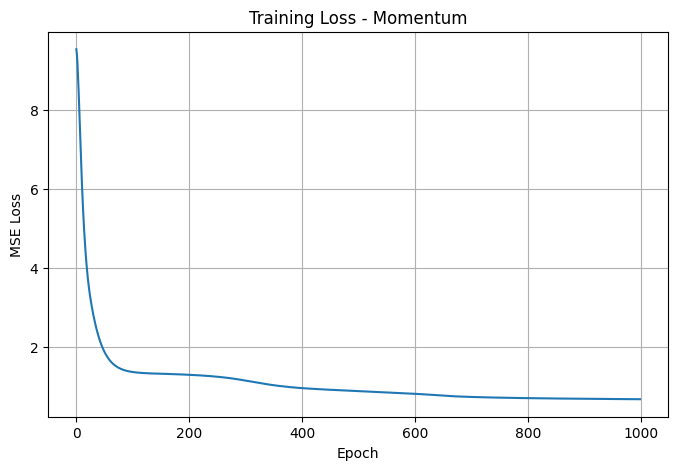

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(momentum_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss - Momentum")

plt.grid(True)
plt.show()

In [32]:
momentum_predictions, _ = forward_propagation(
    X_test,
    momentum_params
)

momentum_mse = mse_loss(
    y_test,
    momentum_predictions
)

momentum_rmse = np.sqrt(momentum_mse)

print("Momentum")
print("----------------------")
print("Test MSE :", momentum_mse)
print("Test RMSE:", momentum_rmse)

Momentum
----------------------
Test MSE : 0.7026376623453959
Test RMSE: 0.8382348491594679


In [33]:
adam_params, adam_losses = train_model(
    X_train,
    y_train,
    optimizer='adam',
    learning_rate=0.001,
    epochs=1000
)

Epoch 1/1000, Loss: 9.531136
Epoch 100/1000, Loss: 6.557564
Epoch 200/1000, Loss: 3.965618
Epoch 300/1000, Loss: 1.382535
Epoch 400/1000, Loss: 0.765731
Epoch 500/1000, Loss: 0.742752
Epoch 600/1000, Loss: 0.723565
Epoch 700/1000, Loss: 0.707173
Epoch 800/1000, Loss: 0.692119
Epoch 900/1000, Loss: 0.678638
Epoch 1000/1000, Loss: 0.666955


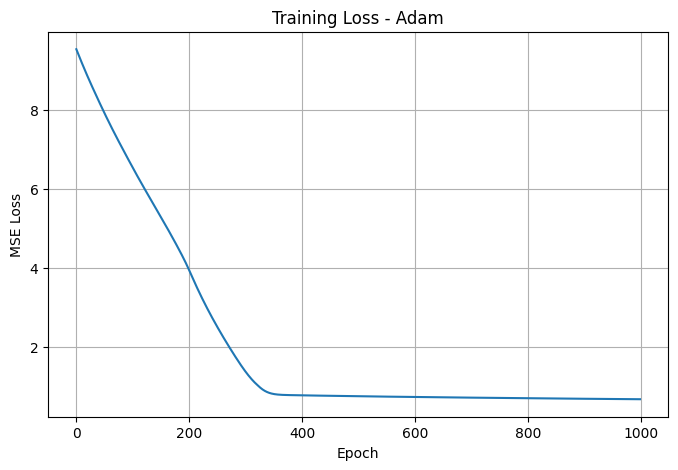

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(adam_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss - Adam")

plt.grid(True)
plt.show()

In [36]:
adam_predictions, _ = forward_propagation(
    X_test,
    adam_params
)

adam_mse = mse_loss(
    y_test,
    adam_predictions
)

adam_rmse = np.sqrt(adam_mse)

print("Adam")
print("----------------------")
print("Test MSE :", adam_mse)
print("Test RMSE:", adam_rmse)

Adam
----------------------
Test MSE : 0.6958689681204412
Test RMSE: 0.8341876096660997


In [37]:
results = pd.DataFrame({
    'Optimizer': [
        'Gradient Descent',
        'Momentum',
        'Adam'
    ],

    'Learning Rate': [
        0.01,
        0.01,
        0.001
    ],

    'Test MSE': [
        gd_mse,
        momentum_mse,
        adam_mse
    ],

    'Test RMSE': [
        gd_rmse,
        momentum_rmse,
        adam_rmse
    ]
})

results

,Optimizer,Learning Rate,Test MSE,Test RMSE
0,Gradient Descent,0.010,0.698379,0.835691
1,Momentum,0.010,0.702638,0.838235
2,Adam,0.001,0.695869,0.834188


In [38]:
best_index = results['Test MSE'].idxmin()

print("Best optimizer:")
print(results.loc[best_index])

Best optimizer:
Optimizer            Adam
Learning Rate       0.001
Test MSE         0.695869
Test RMSE        0.834188
Name: 2, dtype: object


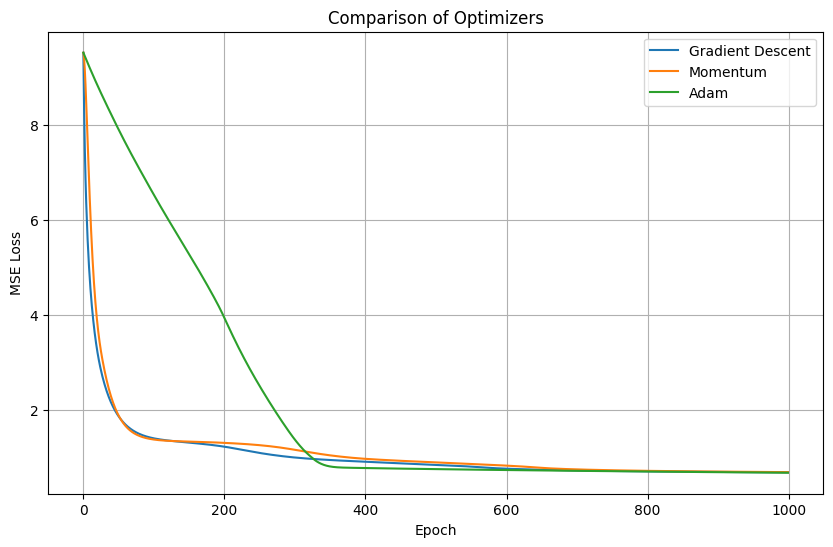

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    gd_losses,
    label="Gradient Descent"
)

plt.plot(
    momentum_losses,
    label="Momentum"
)

plt.plot(
    adam_losses,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Comparison of Optimizers")

plt.legend()
plt.grid(True)

plt.show()

In [40]:
models = {
    'Gradient Descent': (gd_params, gd_mse),
    'Momentum': (momentum_params, momentum_mse),
    'Adam': (adam_params, adam_mse)
}

best_name = min(
    models,
    key=lambda name: models[name][1]
)

best_params = models[best_name][0]

print("Best model:", best_name)

Best model: Adam


In [41]:
best_predictions, _ = forward_propagation(
    X_test,
    best_params
)

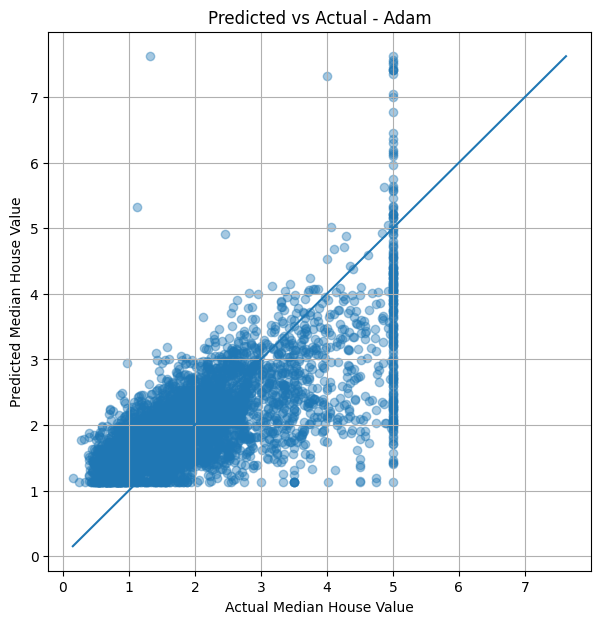

In [42]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.4
)

minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")

plt.title(
    f"Predicted vs Actual - {best_name}"
)

plt.grid(True)
plt.show()